Model Hyparameters Config

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# pai
seed = 42
model = 'llava-v1.5'
# model = 'minigpt4'
# model = "instructblip"
# model = "qwen-vl"
sample = False
temperature = -1
top_p = None
num_beams = 1
max_new_tokens = 512

#hyparams
use_jsd = 1
alpha = 0.6
beta = 0.6
threshold_top_p = 0.9
threshold_top_k = 20
early_exit_layers=[i for i in range(20, 29, 1)]

In [2]:
import argparse
import json
import random
import numpy as np
import torch
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from constants import INSTRUCTION_TEMPLATE, SYSTEM_MESSAGE
from eval_data_loader import COCODataSet
from llava.utils import disable_torch_init
from model_loader import ModelLoader
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from transformers import set_seed
from chair import CHAIR
import pickle

/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


load model

In [3]:
set_seed(seed)
disable_torch_init()

model_loader = ModelLoader(model)

Loading LLava


/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading checkpoint shards: 100%|██████████| 2/2 [00:12<00:00,  6.28s/it]


In [4]:
# image_id = 226988
# image_id = 46011
image_id = 226988
image_path = "/data1/zhr/datasets/coco2014/val2014/" + "COCO_val2014_"+str(image_id).zfill(12) + ".jpg"
image = Image.open(image_path).convert("RGB")

template = INSTRUCTION_TEMPLATE[model]
query = "Please help me describe the image in detail."

if model == "llava-v1.5":
    model_loader.vlm_model.config.image_aspect_ratio = None

questions, kwargs = model_loader.prepare_inputs_for_model(template, query, image_path)

In [5]:
print(questions)

A chat between a curious human and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the human's questions. USER: <image>
Please help me describe the image in detail. ASSISTANT:


In [6]:
# baseline
# with torch.inference_mode():
#     outputs = model_loader.llm_model.generate(
#         do_sample=sample,
#         temperature=temperature,
#         top_p=top_p,
#         num_beams=num_beams,
#         max_new_tokens=max_new_tokens,
#         # min_new_tokens=60,
#         use_cache=True,
#         **kwargs,
#     )

# output_baseline = model_loader.decode(outputs)[0]

In [7]:
use_jsd=3
alpha = 0.6
beta = 0.0
early_exit_layers=[i for i in range(20, 29, 1)]

with torch.inference_mode():
    output_dict, uncond_output_dict = model_loader.llm_model.generate(
        do_sample=sample,
        temperature=temperature,
        top_p=top_p,
        num_beams=num_beams,
        max_new_tokens=max_new_tokens,
        use_cache=True,
        use_jsd=use_jsd,
        alpha = alpha,
        beta = beta,
        threshold_top_p=threshold_top_p, 
        threshold_top_k=threshold_top_k,
        early_exit_layers=early_exit_layers,
        return_dict=True,
        return_dict_in_generate=True,
        output_hidden_states=True,
        output_scores=True,
        **kwargs,
    )

output_ids = output_dict.sequences
outputs = model_loader.decode(output_ids)[0]

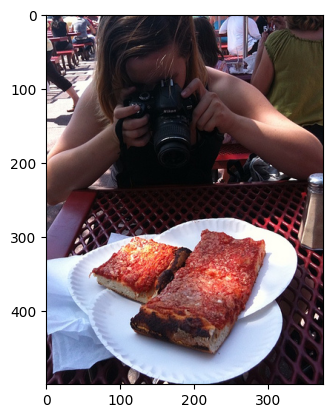

Ours:
 The image depicts a woman sitting at a table, taking pictures of two delicious looking pizzas placed on a plate. She is using a camera to capture the moment, capturing both the pizzas and herself in the process. 

The table is surrounded by chairs, one on each side of the table. There are also two other people visible in the background, one on the left side of the table and another on the right side. Additionally, there are two bottles placed on the table, one near the left side and another near the right side of the table.


In [8]:
plt.imshow(image)
plt.show()
# print("Baseline\n", output_baseline)
# print("\n")
# print("DeCo:\n", deco_outputs)
# print("\n")
print("Ours:\n", outputs)

In [9]:
evaluator = pickle.load(open("/data1/zhr/checkpoints/chair/cache.pkl", 'rb'))
cap_dict = evaluator.compute_sample_chair(outputs, image_id)
print(cap_dict)

{'image_id': 226988, 'caption': 'The image depicts a woman sitting at a table, taking pictures of two delicious looking pizzas placed on a plate. She is using a camera to capture the moment, capturing both the pizzas and herself in the process. \n\nThe table is surrounded by chairs, one on each side of the table. There are also two other people visible in the background, one on the left side of the table and another on the right side. Additionally, there are two bottles placed on the table, one near the left side and another near the right side of the table.', 'mscoco_hallucinated_words': [('chair', 'chair'), ('bottle', 'bottle')], 'mscoco_gt_words': ['dining table', 'pizza', 'person'], 'mscoco_generated_words': ['person', 'dining table', 'pizza', 'pizza', 'dining table', 'chair', 'dining table', 'person', 'dining table', 'bottle', 'dining table', 'dining table'], 'hallucination_idxs': [47, 88], 'metrics': {'CHAIRs': 1, 'CHAIRi': 0.16666666666666666, 'Recall': 1.0, 'Len': 109}}


In [10]:
tokenizer = model_loader.tokenizer
output_ids = output_dict.sequences
if kwargs.get("input_ids", None) is not None:
    input_token_len = kwargs["input_ids"].shape[1]
else:
    input_token_len = 0

target_word = "two  "
start_idx = 0
outputs_tokens = output_ids[0, input_token_len:]
# words = tokenizer.decode(outputs_tokens[start_idx:start_idx+50]).encode("unicode_escape").decode()
for idx, token in enumerate(outputs_tokens[start_idx:]):
    word = tokenizer.decode(token)
    if word in target_word:
        print(start_idx+idx, word, tokenizer.decode(outputs_tokens[start_idx+idx:start_idx+idx+10]))
        break


15 two two delicious looking pizzas placed on a


In [11]:

token_idx = 113
# token_idx = 16
threshold_top_k = 10
layer_logits = []
uncond_layer_logits = []

hidden_states = output_dict.hidden_states[token_idx]
uncond_hidden_states = uncond_output_dict.hidden_states[token_idx]

if model == "qwen-vl":
    layer_norm = model_loader.llm_model.transformer.ln_f
else:
    layer_norm = model_loader.llm_model.model.norm

for layer_id in range(0, 33):
    if layer_id != 32:
        layer_output = layer_norm(hidden_states[layer_id])
        uncond_layer_output = layer_norm(uncond_hidden_states[layer_id])
    else:
        layer_output = hidden_states[layer_id].clone()
        uncond_layer_output = uncond_hidden_states[layer_id].clone()
    logits = model_loader.llm_model.lm_head(layer_output)[:,-1,:]
    uncond_logits = model_loader.llm_model.lm_head(uncond_layer_output)[:,-1,:]
    layer_logits.append(logits)
    uncond_layer_logits.append(uncond_logits)

stacked_layer_logits = torch.stack(layer_logits, dim=0) # shape: (num_layers, batch_size, vocab_size)
stacked_uncond_layer_logits = torch.stack(uncond_layer_logits, dim=0)

layer_softmax = F.softmax(stacked_layer_logits, dim=-1) # shape: (num_layers, batch_size, vocab_size)
uncond_layer_softmax = F.softmax(stacked_uncond_layer_logits, dim=-1)

layer_log_softmax = F.log_softmax(stacked_layer_logits, dim=-1)
uncond_layer_log_softmax =F.log_softmax(stacked_uncond_layer_logits, dim=-1)

final_layer_softmax = layer_softmax[-1, :, :]
final_layer_log_softmax = layer_log_softmax[-1, :, :]

In [13]:
probs = layer_softmax.squeeze()
uncond_probs = uncond_layer_softmax.squeeze()
# probs = layer_log_softmax.squeeze()
# uncond_probs = uncond_layer_log_softmax.squeeze()

candidate_tokens_probs, top_k_candidate_tokens_ids = torch.topk(probs[-1], dim=-1, k=threshold_top_k)

candidate_tokens_cumulative_probs = candidate_tokens_probs.cumsum(dim=-1).float()
candidate_tokens_indices = torch.searchsorted(candidate_tokens_cumulative_probs, threshold_top_p, right=False)
candidate_tokens_cutoff_idx = torch.min(candidate_tokens_indices + 1, torch.tensor(threshold_top_k))   

candidate_tokens_ids = top_k_candidate_tokens_ids[:candidate_tokens_cutoff_idx]

candidate_tokens_early_exit_probs = probs[:,candidate_tokens_ids]
uncond_candidate_tokens_early_exit_probs = uncond_probs[:,candidate_tokens_ids]

top_k_words = [tokenizer.decode(t.cpu()) for t in top_k_candidate_tokens_ids]
top_p_words = [tokenizer.decode(t.cpu()) for t in candidate_tokens_ids]

final_softmax_score = F.softmax(output_dict.scores[token_idx][0], dim=-1)
final_tokens_probs, final_tokens_ids = torch.topk(final_softmax_score, dim=-1, k=threshold_top_k)

final_words = [tokenizer.decode(t.cpu()) for t in final_tokens_ids]

print("top_k_candidate_tokens\n", top_k_words)
print(candidate_tokens_probs)

print("top_p_candidate_tokens\n", top_p_words)
print(candidate_tokens_probs[:candidate_tokens_cutoff_idx])

print("next token logits\n", output_dict.next_token_scores[token_idx][...,candidate_tokens_ids])
print("target layer logits\n", output_dict.target_layer_scores[token_idx][...,candidate_tokens_ids])
print("uncond target layer logits\n", uncond_output_dict.target_layer_scores[token_idx][...,candidate_tokens_ids])
print("target layer max probs: ", output_dict.target_max_probs[token_idx])
print("uncond target layer max probs: ", uncond_output_dict.target_max_probs[token_idx])
print("final logits\n", output_dict.final_scores[token_idx][...,candidate_tokens_ids])

print("final_tokens\n", final_words)
print(final_tokens_probs)


top_k_candidate_tokens
 ['the', 'another', 'one', 'a', 'other', 'an', 'close', 'possibly', 'slightly', 'near']
tensor([6.9434e-01, 2.9858e-01, 6.0081e-03, 7.5197e-04, 9.2626e-05, 3.9220e-05,
        3.5703e-05, 2.7359e-05, 2.1636e-05, 1.9729e-05], device='cuda:0',
       dtype=torch.float16, grad_fn=<TopkBackward0>)
top_p_candidate_tokens
 ['the', 'another']
tensor([0.6943, 0.2986], device='cuda:0', dtype=torch.float16,
       grad_fn=<SliceBackward0>)
next token logits
 tensor([[26.7812, 25.9375]], device='cuda:0')
target layer logits
 tensor([[10.5078, 31.9844]], device='cuda:0', dtype=torch.float16)
uncond target layer logits
 tensor([[28.2812, 27.0469]], device='cuda:0')
target layer max probs:  0.99951171875
uncond target layer max probs:  0.7722573280334473
final logits
 tensor([[33.0820, 45.1250]], device='cuda:0')
final_tokens
 ['another', 'the', '<unk>', '<s>', '<0x03>', '<0x04>', '<0x02>', '<0x01>', '</s>', '<0x00>']
tensor([9.9999e-01, 5.8858e-06, 0.0000e+00, 0.0000e+00, 0.0

In [14]:
# cross layer JSD
M = 0.5 * (layer_softmax[:,:,candidate_tokens_ids] + uncond_layer_softmax[-1, :, candidate_tokens_ids])

kl1 = F.kl_div(layer_log_softmax[:,:,candidate_tokens_ids], M, reduction='none').mean(-1) # shape: (num_layers, batch_size)
kl2 = F.kl_div(uncond_layer_log_softmax[-1, :, candidate_tokens_ids], M, reduction='none').mean(-1)
js_divs = 0.5 * (kl1 + kl2)
cross_layer_js_divs = js_divs.mean(-1) # shape: (num_layers,)

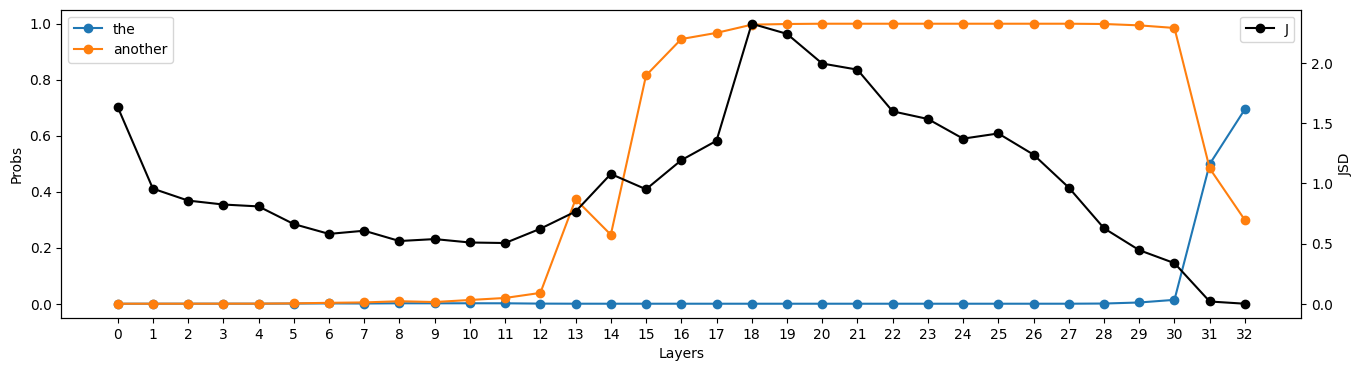

Target Layer idx:  20


In [15]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Probs")
ax.set_xticks(range(33))
# ax.set_ylim(0, 1)
ax.legend(top_p_words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J")

plt.show()
# print("Max JS divergence idx: ", jsd.argmax().item())
print("Target Layer idx: ", output_dict.target_layers[token_idx])

NameError: name 'uncond_candidate_tokens_early_exit_probs' is not defined

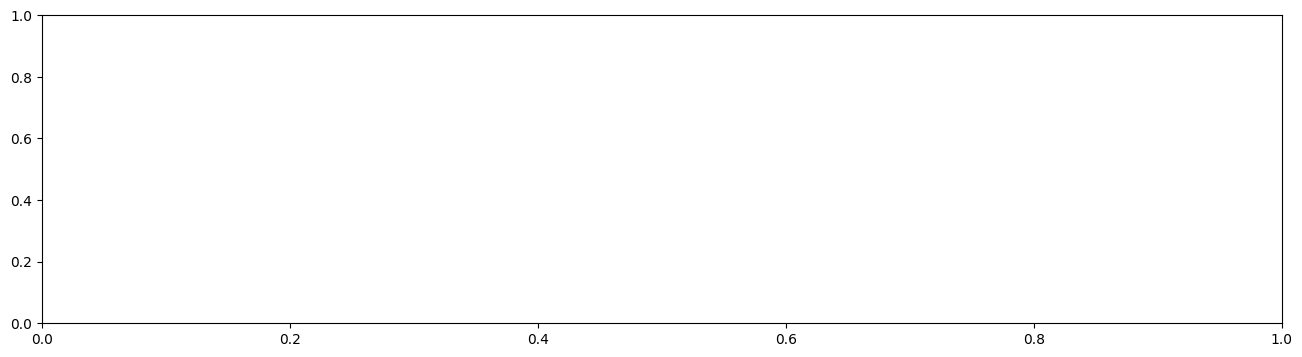

In [16]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(uncond_candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Uncond Probs")
ax.set_xticks(range(33))
ax.set_ylim(0, 1)
ax.legend(top_p_words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J")

plt.show()